In [1]:
from src.utils import load_case_study_data
from src.configs import SySurvConfig
from src.methods import SySurv
from src.evaluation import build_dfd, validate_subgroups
from src.plotting import plot_kaplan_meier

import warnings
warnings.filterwarnings("ignore")

## Load data

In [2]:
dataset = load_case_study_data()

## Discover subgroups

In [3]:
n_subgroups = 5
config = SySurvConfig(contrastive=False, alpha=0.1, lambd=2)
method = SySurv(dataset, config, n_subgroups)

try:
    subgroups, rules = method.run(verbose=False, progress=True, prune=False) # try pruning
except Exception:
    import traceback
    print(traceback.format_exc())

Discovering Subgroup #1


dataset: mmc6_nCounter_PostOp, subgroup # 1, alpha: 0.1, lr: 0.01: 100%|██████████| 1000/1000 [00:03<00:00, 274.17epoch/s, Loss=-35.5, Ns=12]


Discovering Subgroup #2


dataset: mmc6_nCounter_PostOp, subgroup # 2, alpha: 0.1, lr: 0.01: 100%|██████████| 1000/1000 [00:03<00:00, 267.60epoch/s, Loss=-75.8, Ns=49]


Discovering Subgroup #3


dataset: mmc6_nCounter_PostOp, subgroup # 3, alpha: 0.1, lr: 0.01: 100%|██████████| 1000/1000 [00:03<00:00, 265.91epoch/s, Loss=-85.8, Ns=142]


Discovering Subgroup #4


dataset: mmc6_nCounter_PostOp, subgroup # 4, alpha: 0.1, lr: 0.01: 100%|██████████| 1000/1000 [00:03<00:00, 267.08epoch/s, Loss=-122, Ns=13]


Discovering Subgroup #5


dataset: mmc6_nCounter_PostOp, subgroup # 5, alpha: 0.1, lr: 0.01: 100%|██████████| 1000/1000 [00:03<00:00, 251.57epoch/s, Loss=-154, Ns=87]


limegreen -- size: 12 -- rule:
 -6.96 < ALDH1A1 < -3.22 ∧ -6.93 < BCL2L1 < -5.49 ∧ -4.63 < BIRC5 < -1.61 ∧ -2.53 < BNIP3L < -1.15 ∧ -9.04 < CA9 < -4.37 ∧ -5.26 < CBX4 < -3.74 ∧ -5.26 < CLDN4 < -1.31 ∧ -5.21 < CXCL12 < -1.12 ∧ -4.43 < EGLN3 < -0.92 ∧ -0.25 < ENO1 < 1.21 ∧ -5.77 < ENO2 < -2.35 ∧ -7.18 < EPHA1 < -4.64 ∧ -1.72 < GPI < -0.21 ∧ -4.03 < HSPB1 < -2.02 ∧ -4.68 < ITGB2 < -2.29 ∧ -2.30 < KCTD11 < 0.05 ∧ -4.29 < MAP2K2 < -3.30 ∧ -5.77 < MCM6 < -3.96 ∧ -1.87 < MMP13 < 1.74 ∧ -2.72 < MMP9 < 0.55 ∧ -4.98 < MPRS17 < -1.22 ∧ -2.70 < PFKFB3 < -0.21 ∧ -6.61 < PTEN < -5.13 ∧ -1.01 < RAD23B < 0.87 ∧ -5.03 < RB1 < -2.51 ∧ -2.92 < RELA < -1.65 ∧ -7.57 < SERPINB2 < -2.64 ∧ -9.95 < SLC5A1 < -3.61 ∧ -3.80 < TCF3 < -2.29 ∧ -5.15 < XRCC1 < -3.18 ∧ -6.07 < XRCC4 < -4.18 ∧ -2.14 < XRCC5 < -0.57 

dodgerblue -- size: 47 -- rule:
 -2.95 < ANXA5 < -0.89 ∧ -3.76 < ATM < -1.56 ∧ -1.10 < ATP5G3 < 0.96 ∧ -6.08 < BNIP3 < -2.62 ∧ -9.38 < BSG < -5.38 ∧ -8.82 < CD24 < -4.51 ∧ -6.21 < CXCL12 < -1.30 ∧ -7.47 < 

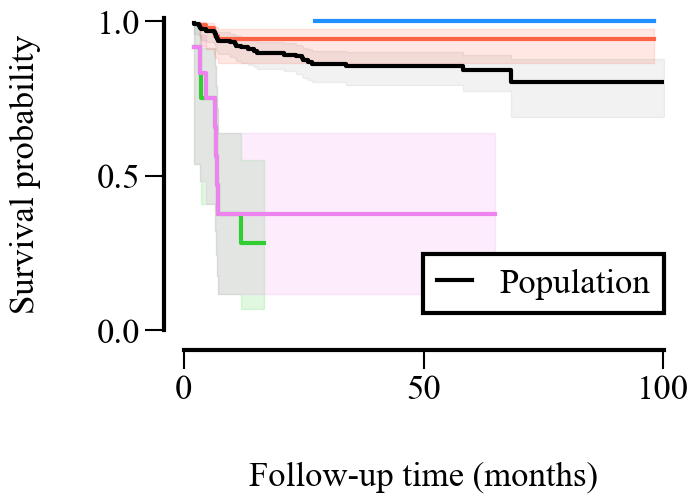

In [4]:
plot_kaplan_meier(dataset, method, sgs=[0, 1, 3, 4])

## Validate subgroups

In [5]:
scrs = build_dfd(dataset, config, runs=20) # number of runs was set to 20 for demonstration only; 1000+ runs is recommended

Building DFD...: 100%|██████████| 20/20 [01:11<00:00,  3.60s/perm]


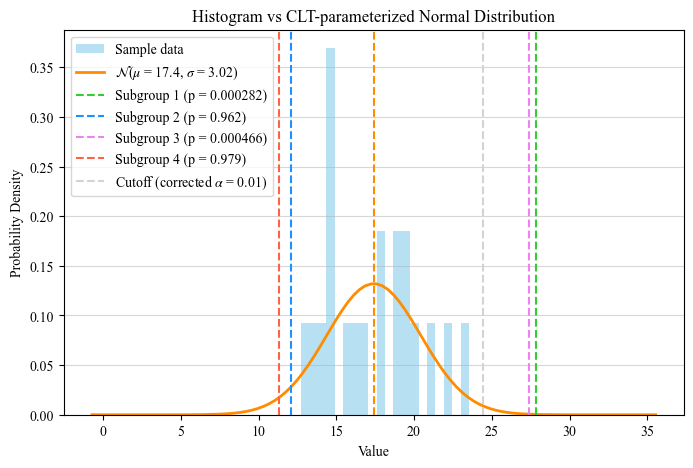

{'mu': 17.400279998779297,
 'sigma': 3.0211424827575684,
 'p_values': [0.0002817903805269529,
  0.9616350975004969,
  0.00046615423726788344,
  0.9786395515809798],
 'corrected_alpha': 0.01,
 'cutoff': np.float64(24.428508390716832),
 'is_significant': [True, False, True, False]}

In [6]:
validate_subgroups(scrs, n_subgroups, [method.best_exceptionalities[i] for i in [0, 1, 3, 4]], plot=True)